# N08 — Interpretabilidad (SHAP global + local)

Este notebook está pensado para la **fase de interpretabilidad** de la tesis, separado del entrenamiento.

Objetivos iniciales de esta versión:

1. **Interpretabilidad global** para el **mejor modelo total** en `1m` y `12m`.
2. **Interpretabilidad local** para el **mejor modelo de ML** en `1m` y `12m`, sobre fechas puntuales.
3. Dejar preparada la estructura para sumar después interpretabilidad local del mejor modelo de **DL** si finalmente decidimos hacerlo con otra técnica.

## Idea metodológica

- **Global:** usar `mean(|SHAP|)` como métrica base y presentarla en términos de **participación porcentual** sobre la importancia total.
- **Local:** usar SHAP por observación para explicar una predicción puntual, mostrando:
  - valor base,
  - contribuciones positivas y negativas,
  - predicción final,
  - tabla resumen interpretable.

## Inputs esperados

Este notebook asume que ya existen:

- `results_n02/df_st_daily_short_plazo.xlsx`
- `results_n02/df_st_daily_long_plazo.xlsx`
- `results_n00/df_daily.xlsx` (nivel del dólar)
- `results_n04/...` y `artifacts_ml/...`
- `results_n05/...` y `artifacts_dl/...`
- `fx_results_all.xlsx` o, en su defecto, los archivos de resultados por familia.

## Nota

En esta primera versión el foco queda puesto en **ML + SHAP**.  
La parte de **DL local** queda preparada como extensión, pero no se fuerza todavía.


In [1]:
# ==========================================
# 0) Imports y configuración general
# ==========================================
import os
import re
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

BASE_DIR = Path.cwd()

DATE_COL = "Fecha"
TARGET_COL = "usd_dlog"
HORIZONS = {"1m": 21, "3m": 63, "6m": 126, "12m": 252}

# Horizonte foco para la tesis (puede ajustarse)
FOCUS_HORIZONS = ["1m", "12m"]

# Parámetros SHAP
GLOBAL_TOP_K_GROUPED = 10
GLOBAL_TOP_K_RAW = 10
SHAP_BG_SAMPLES = 100
SHAP_GLOBAL_SAMPLES = 500
SHAP_LOCAL_MAX_FEATURES = 12

# Carpeta de salida N08
N08_DIR = BASE_DIR / "results_n08"
N08_DIR.mkdir(parents=True, exist_ok=True)

OUT_GLOBAL_DIR = N08_DIR / "global_shap"
OUT_LOCAL_DIR = N08_DIR / "local_shap"
OUT_TABLES_DIR = N08_DIR / "tables"
for d in [OUT_GLOBAL_DIR, OUT_LOCAL_DIR, OUT_TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("N08_DIR:", N08_DIR)


c:\Users\jbrio\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BASE_DIR: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA
N08_DIR: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08


## 1. Carga de resultados y selección de mejores modelos

Primero levantamos la tabla consolidada de resultados.  
Si `fx_results_all.xlsx` no está, el notebook intenta reconstruirla desde los resultados de ML y DL.


In [2]:
# ==========================================
# 1) Carga de resultados consolidados
# ==========================================
def sanitize_model_name(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_]+', '', str(name).replace(" ", "_"))

def load_results_table(base_dir: Path) -> pd.DataFrame:
    direct_xlsx = base_dir / "results_n06" /"fx_results_all.xlsx"
    direct_csv  = base_dir / "results_n06"/ "fx_results_all.csv"

    if direct_xlsx.exists():
        df = pd.read_excel(direct_xlsx)
        print(f"✅ Cargado: {direct_xlsx}")
        return df
    if direct_csv.exists():
        df = pd.read_csv(direct_csv)
        print(f"✅ Cargado: {direct_csv}")
        return df

    parts = []
    ml_csv = base_dir / "results_n04" / "fx_results_ml_all.csv"
    dl_csv = base_dir / "results_n05" / "fx_results_dl.csv"

    if ml_csv.exists():
        parts.append(pd.read_csv(ml_csv))
    if dl_csv.exists():
        parts.append(pd.read_csv(dl_csv))

    if not parts:
        raise FileNotFoundError(
            "No encontré fx_results_all.xlsx/csv ni tampoco resultados_n04/resultados_n05 para reconstruir la tabla."
        )

    df = pd.concat(parts, ignore_index=True)
    print("✅ Tabla reconstruida desde resultados parciales.")
    return df

results_all = load_results_table(BASE_DIR).copy()

# Normalizaciones mínimas
if "model_safe" not in results_all.columns:
    results_all["model_safe"] = results_all["model"].map(sanitize_model_name)

if "family" not in results_all.columns:
    results_all["family"] = np.where(results_all["model"].astype(str).str.contains("LSTM|GRU|CNN|ATTN", case=False, na=False), "dl", "ml")

display(results_all.head())
print(results_all.shape)


✅ Cargado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n06\fx_results_all.xlsx


,h_tag,H_days,model,MAE_level,RMSE_level,R2_level,params,family,model_safe,params_json
0,12m,252,RandomForest,0.433686,0.550427,0.898775,"{'n_estimators': 300, 'min_samples_split': 2, ...",ml,RandomForest,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m..."
1,12m,252,SVR_RBF,0.448687,0.573040,0.894537,"{'svr__C': np.float64(9.846738873614559), 'svr...",ml,SVR_RBF,NaN
2,12m,252,XGBoost,0.459613,0.903659,0.727167,"{'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alp...",ml,XGBoost,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
3,12m,252,LightGBM,0.471413,0.812310,0.779539,"{'subsample': 0.7, 'reg_lambda': 0.1, 'reg_alp...",ml,LightGBM,"{""colsample_bytree"": 0.6, ""learning_rate"": 0.0..."
4,12m,252,CNN_GRU,2.450054,3.086885,-2.704792,"{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}",dl,CNN_GRU,"{""dropout"": 0.3, ""lr"": 0.002, ""units"": 64}"


(63, 10)


In [3]:
# ==========================================
# 1B) Mejores modelos por horizonte
# ==========================================
metric_to_rank = "MAE_level"

ranked = results_all.sort_values(["h_tag", metric_to_rank, "RMSE_level"]).copy()

best_overall = (
    ranked.groupby("h_tag", as_index=False)
          .first()[["h_tag", "H_days", "model", "model_safe", "family", "MAE_level", "RMSE_level", "R2_level"]]
          .sort_values("H_days")
          .reset_index(drop=True)
)

best_ml = (
    ranked.loc[ranked["family"].astype(str).str.lower().eq("ml")]
          .groupby("h_tag", as_index=False)
          .first()[["h_tag", "H_days", "model", "model_safe", "family", "MAE_level", "RMSE_level", "R2_level"]]
          .sort_values("H_days")
          .reset_index(drop=True)
)

best_dl = (
    ranked.loc[ranked["family"].astype(str).str.lower().eq("dl")]
          .groupby("h_tag", as_index=False)
          .first()[["h_tag", "H_days", "model", "model_safe", "family", "MAE_level", "RMSE_level", "R2_level"]]
          .sort_values("H_days")
          .reset_index(drop=True)
)

print("=== Mejor modelo total por horizonte ===")
display(best_overall)

print("=== Mejor modelo ML por horizonte ===")
display(best_ml)

print("=== Mejor modelo DL por horizonte ===")
display(best_dl)


=== Mejor modelo total por horizonte ===


,h_tag,H_days,model,model_safe,family,MAE_level,RMSE_level,R2_level
0,1m,21,RandomForest,RandomForest,ml,0.364530,0.469680,0.920854
1,3m,63,LightGBM,LightGBM,ml,0.376786,0.489653,0.914790
2,6m,126,LightGBM,LightGBM,ml,0.475298,0.643978,0.855705
3,12m,252,RandomForest,RandomForest,ml,0.433686,0.550427,0.898775


=== Mejor modelo ML por horizonte ===


,h_tag,H_days,model,model_safe,family,MAE_level,RMSE_level,R2_level
0,1m,21,RandomForest,RandomForest,ml,0.364530,0.469680,0.920854
1,3m,63,LightGBM,LightGBM,ml,0.376786,0.489653,0.914790
2,6m,126,LightGBM,LightGBM,ml,0.475298,0.643978,0.855705
3,12m,252,RandomForest,RandomForest,ml,0.433686,0.550427,0.898775


=== Mejor modelo DL por horizonte ===


,h_tag,H_days,model,model_safe,family,MAE_level,RMSE_level,R2_level
0,1m,21,LSTM,LSTM,dl,0.890332,1.184915,0.525662
1,3m,63,ATTN_LSTM,ATTN_LSTM,dl,1.415755,1.823736,-0.148973
2,6m,126,CNN_LSTM,CNN_LSTM,dl,2.072003,2.575171,-1.319190
3,12m,252,CNN_GRU,CNN_GRU,dl,2.450054,3.086885,-2.704792


## 2. Carga de bases y helpers de reconstrucción

Para poder recalcular SHAP local/global cuando sea necesario, reproducimos la lógica de construcción de `X` del notebook de ML.


In [4]:
# ==========================================
# 2) Carga de datasets base
# ==========================================
INPUT_SHORT = BASE_DIR / "results_n02" / "df_st_daily_short_plazo.xlsx"
INPUT_LONG  = BASE_DIR / "results_n02" / "df_st_daily_long_plazo.xlsx"
INPUT_LEVEL = BASE_DIR / "results_n00" / "df_daily.xlsx"

for p in [INPUT_SHORT, INPUT_LONG]:
    if not p.exists():
        raise FileNotFoundError(f"No se encontró {p}")

df_short = pd.read_excel(INPUT_SHORT)
df_long  = pd.read_excel(INPUT_LONG)

def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL], errors="coerce")
    out = out.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
    return out

df_short = prepare_df(df_short)
df_long = prepare_df(df_long)

df_level = None
if INPUT_LEVEL.exists():
    df_level = pd.read_excel(INPUT_LEVEL, usecols=["Fecha", "dolar"]).copy()
    df_level["Fecha"] = pd.to_datetime(df_level["Fecha"], errors="coerce")
    df_level = df_level.dropna(subset=["Fecha"]).sort_values("Fecha").drop_duplicates("Fecha").reset_index(drop=True)
    print("✅ Nivel cargado:", INPUT_LEVEL)
else:
    print("⚠️ No encontré results_n00/df_daily.xlsx. Se omiten joins a nivel.")

def get_df_for_tag(tag: str) -> pd.DataFrame:
    if tag in ("1m", "3m"):
        return df_short
    if tag in ("6m", "12m"):
        return df_long
    raise ValueError(f"Horizonte desconocido: {tag}")

print("Short:", df_short.shape, df_short[DATE_COL].min(), "->", df_short[DATE_COL].max())
print("Long :", df_long.shape, df_long[DATE_COL].min(), "->", df_long[DATE_COL].max())


✅ Nivel cargado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n00\df_daily.xlsx
Short: (2584, 52) 2015-04-01 00:00:00 -> 2025-09-05 00:00:00
Long : (2584, 52) 2015-04-01 00:00:00 -> 2025-09-05 00:00:00


In [5]:
# ==========================================
# 2B) Helpers de features (misma lógica N04)
# ==========================================
MONTHLY_FEATURES_OVERRIDE = None
MONTHLY_NUNIQUE_MEDIAN_THRESHOLD = 2.0

def future_sum(series: pd.Series, H: int) -> pd.Series:
    base = series.astype(float)
    return base.shift(-1).rolling(H).sum().shift(-(H - 1))

def infer_monthly_features(df: pd.DataFrame, feature_cols, threshold_median_nunique: float = 1.0):
    if len(feature_cols) == 0:
        return set()

    m = pd.to_datetime(df[DATE_COL]).dt.to_period("M")
    monthly = set()
    for c in feature_cols:
        try:
            nun = df.groupby(m)[c].nunique(dropna=True)
            if float(nun.median()) <= float(threshold_median_nunique):
                monthly.add(c)
        except Exception:
            pass
    return monthly

def build_xy_by_h(
    df: pd.DataFrame,
    target_col: str,
    H: int,
    use_freq_aware_lags: bool = True,
    lag_daily: int = 2,
    lag_monthly: int = 21,
    daily_lags=None,
    monthly_lags=None,
    target_lags=None,
    monthly_features_override=None,
    monthly_threshold_median_nunique: float = 1.0,
):
    df = df.copy()
    y = future_sum(df[target_col], H).rename(f"r_{H}")

    feats = [c for c in df.columns if c not in [target_col, DATE_COL] and pd.api.types.is_numeric_dtype(df[c])]
    X_parts = []

    if use_freq_aware_lags:
        if daily_lags is None:
            daily_lags = [lag_daily]
        if monthly_lags is None:
            monthly_lags = [lag_monthly]
        if target_lags is None:
            target_lags = list(daily_lags)

        daily_lags = sorted(set(int(x) for x in daily_lags))
        monthly_lags = sorted(set(int(x) for x in monthly_lags))
        target_lags = sorted(set(int(x) for x in target_lags))

        if monthly_features_override is not None:
            monthly_feats = set(monthly_features_override)
        else:
            monthly_feats = infer_monthly_features(
                df,
                feats,
                threshold_median_nunique=monthly_threshold_median_nunique,
            )

        for c in feats:
            lag_list = monthly_lags if c in monthly_feats else daily_lags
            for L in lag_list:
                X_parts.append(df[c].shift(L).rename(f"{c}_L{L}"))

        for L in target_lags:
            X_parts.append(df[target_col].shift(L).rename(f"{target_col}_L{L}"))

    else:
        raise NotImplementedError("Este N08 asume la versión freq-aware usada en N04.")

    X = pd.concat(X_parts, axis=1)
    XY = pd.concat([df[[DATE_COL]], X, y], axis=1).dropna().reset_index(drop=True)

    dates_clean = XY[DATE_COL].copy()
    y_clean = XY[y.name].copy()
    X_clean = XY.drop(columns=[DATE_COL, y.name]).copy()
    return X_clean, y_clean, dates_clean

def base_feature_name(feat: str) -> str:
    return feat.split("_L")[0] if "_L" in str(feat) else feat


## 3. Carga de artefactos ML y utilidades SHAP

Esta sección busca dos cosas:

1. reutilizar directamente los archivos SHAP ya guardados si existen;
2. si hace falta, recalcular SHAP sobre el mejor modelo usando el artefacto guardado.


In [6]:
# ==========================================
# 3) Utilidades para artefactos y SHAP
# ==========================================
import joblib

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_ml_artifact(h_tag: str, model_safe: str):
    art_dir = BASE_DIR / "artifacts_ml" / h_tag / model_safe
    if not art_dir.exists():
        art_dir = BASE_DIR / "results_n04" / "artifacts_ml" / h_tag / model_safe

    if not art_dir.exists():
        raise FileNotFoundError(f"No encontré artefactos ML para {h_tag}/{model_safe}")

    model = joblib.load(art_dir / "model.joblib")
    features = load_json(art_dir / "features.json")
    params = load_json(art_dir / "params.json") if (art_dir / "params.json").exists() else {}
    metadata = load_json(art_dir / "metadata.json") if (art_dir / "metadata.json").exists() else {}
    return {"dir": art_dir, "model": model, "features": features, "params": params, "metadata": metadata}

def find_saved_shap_csv(h_tag: str, model_safe: str, kind: str = "grouped"):
    assert kind in {"grouped", "raw"}
    candidates = [
        BASE_DIR / "results_n04" / "feature_importance" / f"shap_importance_{kind}_{h_tag}_{model_safe}.csv",
        BASE_DIR / f"shap_importance_{kind}_{h_tag}_{model_safe}.csv",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def recover_lag_lists_from_features(features):
    daily_lags, monthly_lags, target_lags = set(), set(), set()
    for f in features:
        m = re.match(r"(.+)_L(\d+)$", str(f))
        if not m:
            continue
        base, lag = m.group(1), int(m.group(2))
        if base == TARGET_COL:
            target_lags.add(lag)
        else:
            # Se infiere después contra el conjunto de variables mensuales
            daily_lags.add(lag)
            monthly_lags.add(lag)
    return sorted(daily_lags), sorted(monthly_lags), sorted(target_lags)

def build_X_exact_from_artifact(h_tag: str, features: list):
    df = get_df_for_tag(h_tag)
    H = HORIZONS[h_tag]

    monthly_feats = infer_monthly_features(
        df,
        [c for c in df.columns if c not in [DATE_COL, TARGET_COL] and pd.api.types.is_numeric_dtype(df[c])],
        threshold_median_nunique=MONTHLY_NUNIQUE_MEDIAN_THRESHOLD,
    ) if MONTHLY_FEATURES_OVERRIDE is None else set(MONTHLY_FEATURES_OVERRIDE)

    # Recuperamos lags observados en features.
    daily_lags_seen, monthly_lags_seen, target_lags = recover_lag_lists_from_features(features)

    # Ajustamos daily/monthly según los features efectivamente presentes.
    daily_lags = sorted({
        int(re.search(r"_L(\d+)$", f).group(1))
        for f in features
        if re.search(r"_L(\d+)$", str(f)) and base_feature_name(f) not in monthly_feats and base_feature_name(f) != TARGET_COL
    })
    monthly_lags = sorted({
        int(re.search(r"_L(\d+)$", f).group(1))
        for f in features
        if re.search(r"_L(\d+)$", str(f)) and base_feature_name(f) in monthly_feats
    })

    X_all, y_all, dates_all = build_xy_by_h(
        df=df,
        target_col=TARGET_COL,
        H=H,
        use_freq_aware_lags=True,
        daily_lags=daily_lags if daily_lags else [2],
        monthly_lags=monthly_lags if monthly_lags else [21],
        target_lags=target_lags if target_lags else ([2] if daily_lags else [2]),
        monthly_features_override=monthly_feats,
        monthly_threshold_median_nunique=MONTHLY_NUNIQUE_MEDIAN_THRESHOLD,
    )

    missing = [c for c in features if c not in X_all.columns]
    if missing:
        raise ValueError(f"Hay features del artefacto que no pude reconstruir: {missing[:10]}")

    X_all = X_all[features].copy()
    return X_all, y_all, dates_all

def get_tree_shap_explainer(model, X_bg):
    import shap
    return shap.TreeExplainer(model, data=X_bg)

print("Helpers listos.")


Helpers listos.


## 4. SHAP global del mejor modelo total

La idea de presentación es:

- **Panel A:** top variables agrupadas (`feature_base`) como **% del total**.
- **Panel B:** top variables raw (lags concretos) también como % del total.
- Más adelante, si preservamos la matriz completa de SHAP por observación, podemos sumar un beeswarm.


In [41]:
# ==========================================
# 4) Helpers para SHAP global
# ==========================================
def add_shap_shares(df: pd.DataFrame, value_col: str = "shap_mean_abs") -> pd.DataFrame:
    out = df.copy()
    total = out[value_col].sum()
    out["share_total"] = np.where(total > 0, out[value_col] / total, np.nan)
    out["share_pct"] = 100 * out["share_total"]
    return out

def compute_global_shap_from_model(h_tag: str, model_name: str, model_safe: str,
                                   shap_n_samples: int = SHAP_GLOBAL_SAMPLES,
                                   bg_n_samples: int = SHAP_BG_SAMPLES):
    import shap

    art = load_ml_artifact(h_tag, model_safe)
    X_all, y_all, dates_all = build_X_exact_from_artifact(h_tag, art["features"])

    n = len(X_all)
    n_shap = min(int(shap_n_samples), n)
    X_shap = X_all.iloc[-n_shap:].copy()

    n_bg = min(int(bg_n_samples), len(X_shap))
    X_bg = X_shap.iloc[:n_bg].copy()

    explainer = shap.TreeExplainer(art["model"], data=X_bg)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)

    imp = np.mean(np.abs(shap_values), axis=0)

    df_raw = pd.DataFrame({
        "h_tag": h_tag,
        "H_days": HORIZONS[h_tag],
        "model": model_name,
        "feature": X_shap.columns,
        "shap_mean_abs": imp,
    }).sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

    df_raw["feature_base"] = df_raw["feature"].map(base_feature_name)
    df_grp = (
        df_raw.groupby(["h_tag", "H_days", "model", "feature_base"], as_index=False)["shap_mean_abs"]
              .sum()
              .sort_values("shap_mean_abs", ascending=False)
              .reset_index(drop=True)
    )

    return {
        "artifact": art,
        "X_shap": X_shap,
        "dates_shap": dates_all.iloc[-n_shap:].reset_index(drop=True),
        "shap_values": shap_values,
        "raw": add_shap_shares(df_raw),
        "grouped": add_shap_shares(df_grp),
    }

def load_or_compute_global_shap(h_tag: str, model_name: str, model_safe: str, force_recompute: bool = False):
    raw_p = find_saved_shap_csv(h_tag, model_safe, "raw")
    grp_p = find_saved_shap_csv(h_tag, model_safe, "grouped")

    if (not force_recompute) and raw_p and grp_p:
        df_raw = add_shap_shares(pd.read_csv(raw_p))
        df_grp = add_shap_shares(pd.read_csv(grp_p))
        return {"raw": df_raw, "grouped": df_grp, "from_saved_csv": True, "raw_path": raw_p, "grouped_path": grp_p}

    out = compute_global_shap_from_model(h_tag, model_name, model_safe)
    out["from_saved_csv"] = False
    return out

def plot_global_shap(df_grouped, h_tag, model_name, top_k=10, save=True):
    """
    Gráfico único de SHAP global a nivel agregado por variable base.
    """
    g = df_grouped.head(top_k).sort_values("share_pct", ascending=True).copy()

    fig, ax = plt.subplots(figsize=(9.5, 5.4))

    ax.barh(g["feature_base"], g["share_pct"])
    ax.set_title(f"{h_tag} | SHAP global", fontsize=13, pad=12)
    ax.set_xlabel("% del total de |SHAP|")
    ax.grid(axis="x", alpha=0.25)

    # Márgenes para que no se corten las etiquetas
    x_min = 0.0
    x_max = float(g["share_pct"].max())
    x_span = max(x_max - x_min, 1e-9)
    pad = max(x_span * 0.14, 1.0)
    text_offset = max(x_span * 0.012, 0.12)

    for i, v in enumerate(g["share_pct"]):
        ax.text(
            v + text_offset,
            i,
            f"{v:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
        )

    ax.set_xlim(x_min, x_max + pad)

    plt.suptitle(f"{model_name} — horizonte {h_tag}", y=0.98, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save:
        out = OUT_GLOBAL_DIR / f"global_shap_{h_tag}_{sanitize_model_name(model_name)}.png"
        plt.savefig(out, dpi=180, bbox_inches="tight")
        print("✅ Figura guardada en:", out)

    plt.show()



GLOBAL SHAP | h_tag=1m | model=RandomForest | family=ml


,h_tag,H_days,model,feature_base,shap_mean_abs,rank,share_total,share_pct
0,1m,21,RandomForest,exp_brl,0.001191,1,0.064731,6.473143
1,1m,21,RandomForest,imp_EU,0.000963,2,0.052317,5.231749
2,1m,21,RandomForest,exp_quimicos,0.000937,3,0.050923,5.092280
3,1m,21,RandomForest,exp_carne,0.000854,4,0.046409,4.640885
4,1m,21,RandomForest,derivados_financieros,0.000833,5,0.045256,4.525644
5,1m,21,RandomForest,tasa_pesos_familias,0.000795,6,0.043229,4.322869
6,1m,21,RandomForest,exp_arg,0.000785,7,0.042668,4.266821
7,1m,21,RandomForest,IMESI,0.000764,8,0.041531,4.153145
8,1m,21,RandomForest,imp_chn,0.000760,9,0.041306,4.130630
9,1m,21,RandomForest,adq_neta_act_financieros,0.000737,10,0.040044,4.004414


✅ Figura guardada en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\global_shap\global_shap_1m_RandomForest.png


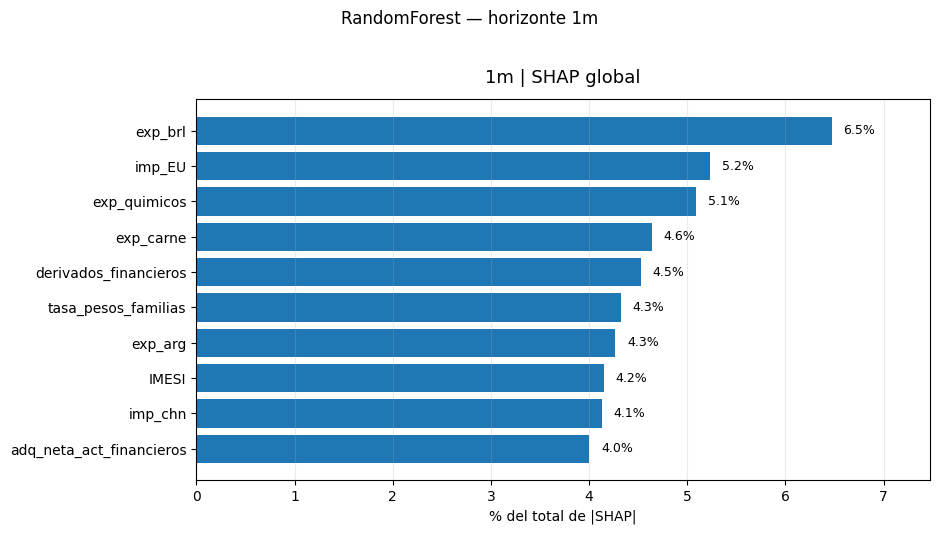


GLOBAL SHAP | h_tag=12m | model=RandomForest | family=ml


,h_tag,H_days,model,feature_base,shap_mean_abs,rank,share_total,share_pct
0,12m,252,RandomForest,tasa_desempleo_usa,0.033373,1,0.295387,29.538674
1,12m,252,RandomForest,tasa_dolares_familias,0.008596,2,0.076080,7.608012
2,12m,252,RandomForest,adq_neta_act_financieros,0.006892,3,0.061005,6.100465
3,12m,252,RandomForest,dolar_mexico,0.006790,4,0.060094,6.009383
4,12m,252,RandomForest,derivados_financieros,0.006668,5,0.059019,5.901919
5,12m,252,RandomForest,inversion_de_cartera,0.004538,6,0.040164,4.016377
6,12m,252,RandomForest,exp_quimicos,0.004302,7,0.038075,3.807472
7,12m,252,RandomForest,imp_arg,0.004215,8,0.037308,3.730769
8,12m,252,RandomForest,imp_EU,0.003783,9,0.033480,3.347977
9,12m,252,RandomForest,VIX,0.003460,10,0.030627,3.062724


✅ Figura guardada en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\global_shap\global_shap_12m_RandomForest.png


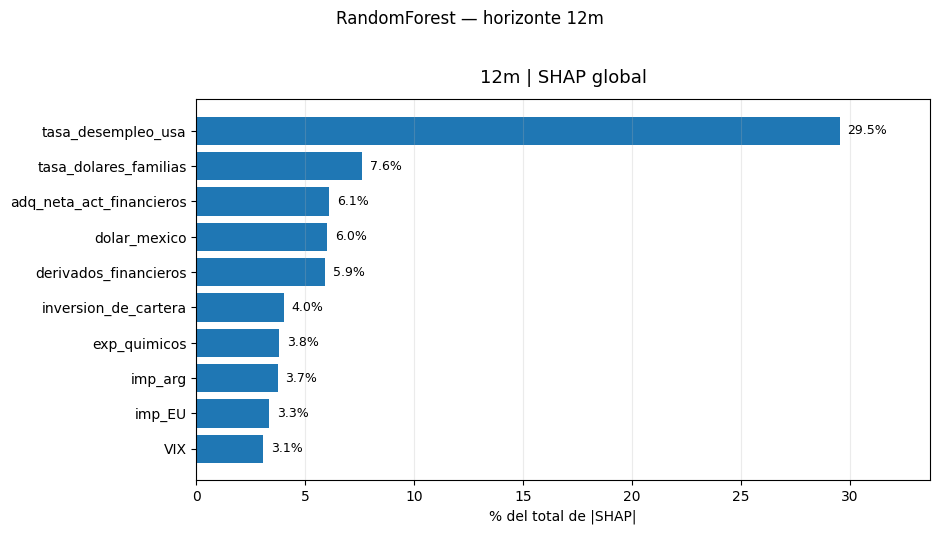

In [42]:
# ==========================================
# 4B) Ejecutar SHAP global para 1m y 12m
# ==========================================
global_outputs = {}

for h_tag in FOCUS_HORIZONS:
    row = best_overall.loc[best_overall["h_tag"].eq(h_tag)].iloc[0]
    print("\n" + "="*80)
    print(f"GLOBAL SHAP | h_tag={h_tag} | model={row['model']} | family={row['family']}")
    print("="*80)

    # Si el mejor total no es ML, hoy no intentamos SHAP aquí.
    if str(row["family"]).lower() != "ml":
        print("⚠️ El mejor modelo total no es ML. Esta versión solo automatiza SHAP para árboles/ML.")
        continue

    out = load_or_compute_global_shap(h_tag, row["model"], row["model_safe"], force_recompute=False)
    global_outputs[h_tag] = out

    # Mostrar solo el SHAP global agregado
    display(out["grouped"].head(15))

    # Guardar solo tabla agregada transformada
    out["grouped"].to_csv(
        OUT_TABLES_DIR / f"global_shap_{h_tag}_{row['model_safe']}.csv",
        index=False
    )

    # Graficar solo el agregado, pero nombrándolo simplemente SHAP global
    plot_global_shap(
        df_grouped=out["grouped"],
        h_tag=h_tag,
        model_name=row["model"],
        top_k=GLOBAL_TOP_K_GROUPED,
        save=True,
    )

### Lectura rápida del SHAP global

Estas celdas no son obligatorias, pero ayudan a producir texto para tesis de manera más sistemática.


In [9]:
# ==========================================
# 4C) Resumen textual automatizado
# ==========================================
def summarize_global(df_grouped, top_n=5):
    top = df_grouped.head(top_n)[["feature_base", "share_pct"]].copy()
    accum = top["share_pct"].sum()
    print(f"Top {top_n} variables explican {accum:.1f}% de la importancia global total.")
    display(top)

for h_tag, out in global_outputs.items():
    print("\n---", h_tag, "---")
    summarize_global(out["grouped"], top_n=5)



--- 1m ---
Top 5 variables explican 26.0% de la importancia global total.


,feature_base,share_pct
0,exp_brl,6.473143
1,imp_EU,5.231749
2,exp_quimicos,5.092280
3,exp_carne,4.640885
4,derivados_financieros,4.525644



--- 12m ---
Top 5 variables explican 55.2% de la importancia global total.


,feature_base,share_pct
0,tasa_desempleo_usa,29.538674
1,tasa_dolares_familias,7.608012
2,adq_neta_act_financieros,6.100465
3,dolar_mexico,6.009383
4,derivados_financieros,5.901919


## 4D. Extensión del SHAP global: dirección y dispersión por variable base

In [10]:

# ==========================================
# 4D) Helpers adicionales: detalle global, dirección/dispersión y diagnóstico
# ==========================================
def ensure_global_detail_bundle(h_tag: str, force_if_needed: bool = True):
    """
    Asegura un bundle detallado con matriz SHAP por observación y, al mismo tiempo,
    preserva como 'oficial' el ranking grouped/raw que ya venía del notebook
    (por ejemplo, desde archivos CSV guardados).
    """
    if h_tag not in global_outputs:
        raise KeyError(f"No existe salida global para {h_tag}. Revisá la sección 4B.")

    out = global_outputs[h_tag]

    if "raw_official" not in out:
        out["raw_official"] = out["raw"].copy()
    if "grouped_official" not in out:
        out["grouped_official"] = out["grouped"].copy()

    has_detail = all(k in out for k in ["artifact", "X_shap", "dates_shap", "shap_values"])
    if has_detail:
        global_outputs[h_tag] = out
        return out

    if not force_if_needed:
        global_outputs[h_tag] = out
        return out

    row = best_overall.loc[best_overall["h_tag"].eq(h_tag)].iloc[0]
    if str(row["family"]).lower() != "ml":
        raise ValueError(f"El mejor modelo total en {h_tag} no es ML; no puedo recomputar TreeSHAP.")

    print(f"ℹ️ Recomputo bundle detallado para {h_tag} porque venía desde CSV guardado.")
    detail = compute_global_shap_from_model(h_tag, row["model"], row["model_safe"])
    detail["from_saved_csv"] = False

    # Preservar la versión oficial para ranking / shares globales
    detail["raw_official"] = out["raw_official"].copy()
    detail["grouped_official"] = out["grouped_official"].copy()

    global_outputs[h_tag] = detail
    return detail


def build_grouped_net_shap_matrix(out: dict):
    """
    Construye una matriz de SHAP neto agrupado por variable base, a nivel observación.
    Cada columna es una variable base y cada fila una observación.
    """
    if "X_shap" not in out or "shap_values" not in out:
        raise ValueError("Este bundle no trae X_shap y shap_values. Ejecutá ensure_global_detail_bundle(...) primero.")

    X_shap = out["X_shap"].copy()
    shap_values = np.asarray(out["shap_values"])
    shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

    feat_map = pd.DataFrame({
        "feature": X_shap.columns,
        "feature_base": [base_feature_name(c) for c in X_shap.columns]
    })

    shap_grouped = pd.DataFrame(index=shap_df.index)
    x_grouped = pd.DataFrame(index=X_shap.index)

    for b in feat_map["feature_base"].unique():
        cols_b = feat_map.loc[feat_map["feature_base"].eq(b), "feature"].tolist()
        shap_grouped[b] = shap_df[cols_b].sum(axis=1)
        # Proxy descriptiva para acompañar la lectura de la variable base
        x_grouped[b] = X_shap[cols_b].mean(axis=1)

    return shap_grouped, x_grouped, feat_map


def summarize_grouped_signed_distribution(shap_grouped_df: pd.DataFrame, top_bases: list):
    rows = []
    for b in top_bases:
        if b not in shap_grouped_df.columns:
            continue
        vals = shap_grouped_df[b].dropna().values
        rows.append({
            "feature_base": b,
            "mean_signed": np.mean(vals),
            "median_signed": np.median(vals),
            "p25": np.percentile(vals, 25),
            "p75": np.percentile(vals, 75),
            "p10": np.percentile(vals, 10),
            "p90": np.percentile(vals, 90),
            "std_signed": np.std(vals),
        })
    return pd.DataFrame(rows)


def plot_grouped_signed_boxplot(h_tag: str, out: dict, top_k: int = 10, save: bool = True):
    """
    Figura complementaria al ranking grouped oficial:
    boxplot horizontal de contribuciones SHAP netas agrupadas por variable base.
    El ORDEN se toma del grouped oficial para no mezclar métricas.
    """
    grouped_official = out.get("grouped_official", out["grouped"]).copy()
    top_bases = grouped_official.head(top_k)["feature_base"].tolist()

    shap_grouped, x_grouped, feat_map = build_grouped_net_shap_matrix(out)
    available_bases = [b for b in top_bases if b in shap_grouped.columns]
    data = [shap_grouped[b].dropna().values for b in available_bases]

    fig, ax = plt.subplots(figsize=(10, 6))
    bp = ax.boxplot(
        data,
        vert=False,
        labels=available_bases,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.3},
        boxprops={"facecolor": "#9ecae1", "edgecolor": "#4a4a4a"},
        whiskerprops={"color": "#4a4a4a"},
        capprops={"color": "#4a4a4a"},
    )
    ax.axvline(0, color="black", lw=1, alpha=0.8)
    ax.set_title(f"{h_tag} | Distribución de contribuciones SHAP netas agrupadas")
    ax.set_xlabel("SHAP neto agrupado")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()

    summary = summarize_grouped_signed_distribution(shap_grouped, available_bases)

    if save:
        row = best_overall.loc[best_overall["h_tag"].eq(h_tag)].iloc[0]
        out_path = OUT_GLOBAL_DIR / f"global_grouped_signed_box_{h_tag}_{row['model_safe']}.png"
        plt.savefig(out_path, dpi=180, bbox_inches="tight")
        print("✅ Boxplot signed agrupado guardado en:", out_path)

        summary_path = OUT_TABLES_DIR / f"global_grouped_signed_summary_{h_tag}_{row['model_safe']}.csv"
        summary.to_csv(summary_path, index=False)
        print("✅ Resumen signed agrupado guardado en:", summary_path)

    plt.show()
    return {"top_bases": available_bases, "shap_grouped": shap_grouped, "x_grouped": x_grouped,
            "feature_map": feat_map, "summary": summary}


def inspect_global_base_feature(out: dict, base_feature: str, top_lags: int = 20):
    raw = out.get("raw_official", out["raw"]).copy()
    grp = out.get("grouped_official", out["grouped"]).copy()

    g = grp.loc[grp["feature_base"].eq(base_feature)].copy()
    if g.empty:
        print(f"No encontré {base_feature} en el ranking agrupado.")
        return None

    r = raw.loc[raw["feature_base"].eq(base_feature)].copy()
    r = r.sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

    total_base = r["shap_mean_abs"].sum()
    r["share_within_base"] = np.where(total_base > 0, r["shap_mean_abs"] / total_base, np.nan)
    r["share_within_base_pct"] = 100 * r["share_within_base"]

    print("="*90)
    print(f"Diagnóstico SHAP global | variable base = {base_feature}")
    print("="*90)
    display(g[["feature_base", "shap_mean_abs", "share_pct"]])

    print("\nTop lags asociados:")
    display(r.head(top_lags)[["feature", "shap_mean_abs", "share_pct", "share_within_base_pct"]])

    return r


def plot_top_raw_correlation(out: dict, top_n: int = 15, save: bool = True):
    X = out["X_shap"].copy()
    raw_official = out.get("raw_official", out["raw"]).copy()
    top_feats = raw_official.head(top_n)["feature"].tolist()
    corr = X[top_feats].corr()

    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(corr, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=90)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats)
    ax.set_title(f"Correlación entre top {top_n} features raw")
    plt.tight_layout()

    if save:
        row = best_overall.loc[best_overall["h_tag"].eq(out.get('raw_official', out['raw'])['h_tag'].iloc[0])].iloc[0]
        out_path = OUT_GLOBAL_DIR / f"corr_top_raw_{out.get('raw_official', out['raw'])['h_tag'].iloc[0]}_{row['model_safe']}.png"
        plt.savefig(out_path, dpi=180, bbox_inches="tight")
        print("✅ Heatmap de correlación guardado en:", out_path)

    plt.show()
    return corr


def perturb_feature_family(X: pd.DataFrame, base_feature: str, method: str = "median", random_state: int = 42):
    cols = [c for c in X.columns if base_feature_name(c) == base_feature]
    if len(cols) == 0:
        raise ValueError(f"No encontré columnas para la variable base '{base_feature}'")

    X_new = X.copy()
    rng = np.random.default_rng(random_state)

    for c in cols:
        if method == "median":
            X_new[c] = X_new[c].median()
        elif method == "zero":
            X_new[c] = 0.0
        elif method == "permute":
            X_new[c] = rng.permutation(X_new[c].values)
        else:
            raise ValueError("method debe ser 'median', 'zero' o 'permute'")
    return X_new, cols


def feature_family_sensitivity_test(out: dict, base_feature: str, methods=("median", "permute", "zero"), random_state: int = 42):
    model = out["artifact"]["model"]
    X = out["X_shap"].copy()
    X_all, y_all, dates_all = build_X_exact_from_artifact(out.get("raw_official", out["raw"])["h_tag"].iloc[0], out["artifact"]["features"])
    y = y_all.iloc[-len(X):].reset_index(drop=True)
    X = X.reset_index(drop=True)

    pred_base = model.predict(X)
    rows = [{
        "scenario": "original",
        "base_feature": base_feature,
        "n_cols_affected": 0,
        "rmse": np.sqrt(mean_squared_error(y, pred_base)),
        "mae": mean_absolute_error(y, pred_base),
        "r2": r2_score(y, pred_base),
    }]

    for method in methods:
        X_mod, cols = perturb_feature_family(X, base_feature, method=method, random_state=random_state)
        pred_mod = model.predict(X_mod)
        row = {
            "scenario": method,
            "base_feature": base_feature,
            "n_cols_affected": len(cols),
            "rmse": np.sqrt(mean_squared_error(y, pred_mod)),
            "mae": mean_absolute_error(y, pred_mod),
            "r2": r2_score(y, pred_mod),
        }
        row["delta_rmse"] = row["rmse"] - rows[0]["rmse"]
        row["delta_mae"] = row["mae"] - rows[0]["mae"]
        row["delta_r2"] = row["r2"] - rows[0]["r2"]
        rows.append(row)

    return pd.DataFrame(rows)


### 4E. Ejecución: boxplot signed agrupado y auditoría de variable dominante


EXTENSIÓN GLOBAL | 1m
ℹ️ Recomputo bundle detallado para 1m porque venía desde CSV guardado.


 97%|=================== | 484/500 [00:24<00:00]       

✅ Boxplot signed agrupado guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\global_shap\global_grouped_signed_box_1m_RandomForest.png
✅ Resumen signed agrupado guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\tables\global_grouped_signed_summary_1m_RandomForest.csv


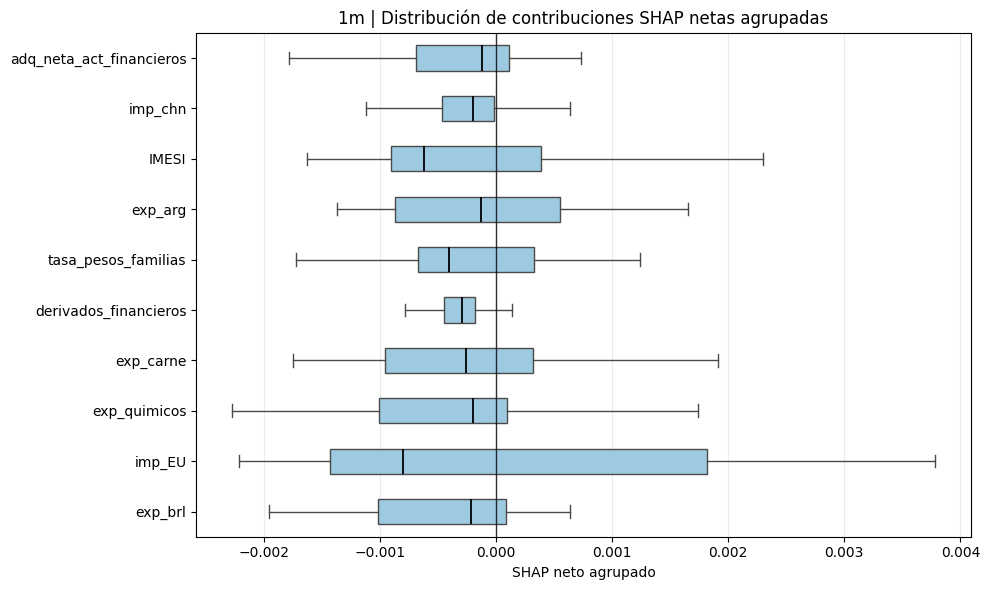

✅ Heatmap de correlación guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\global_shap\corr_top_raw_1m_RandomForest.png


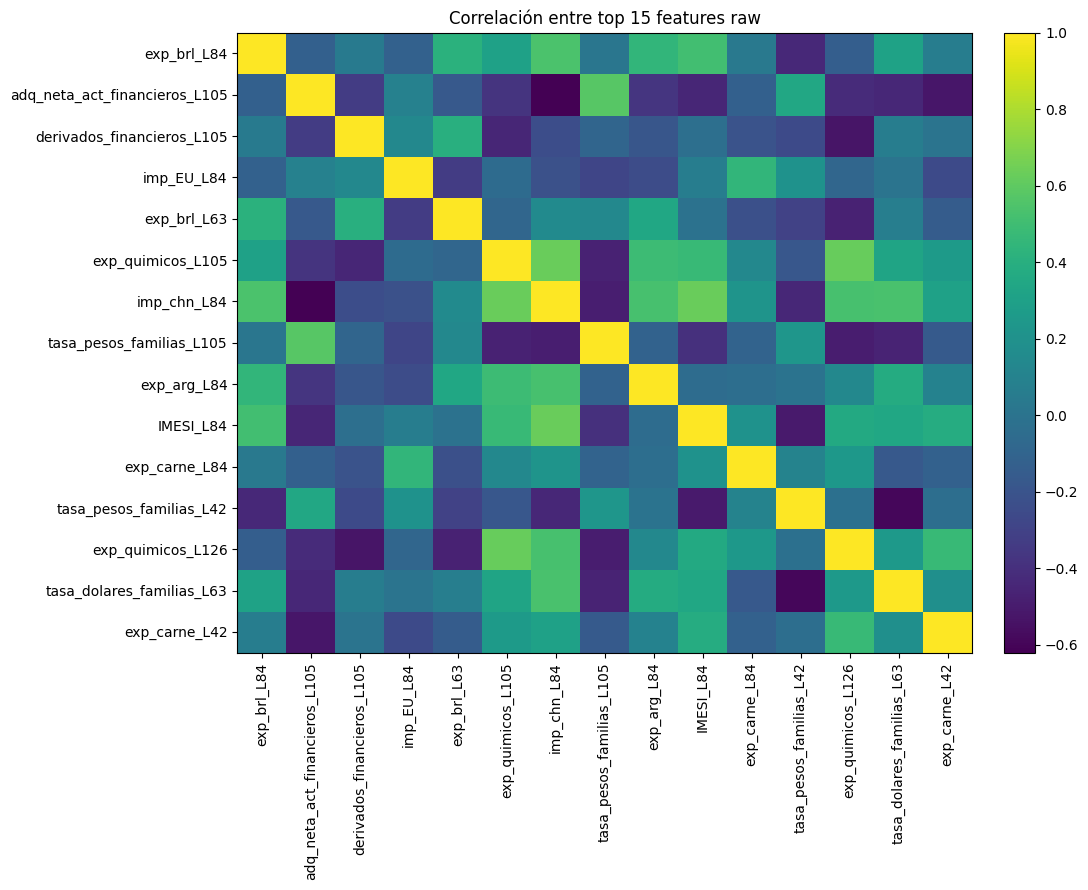


EXTENSIÓN GLOBAL | 12m
ℹ️ Recomputo bundle detallado para 12m porque venía desde CSV guardado.


 96%|=================== | 480/500 [00:21<00:00]       

✅ Boxplot signed agrupado guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\global_shap\global_grouped_signed_box_12m_RandomForest.png
✅ Resumen signed agrupado guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\tables\global_grouped_signed_summary_12m_RandomForest.csv


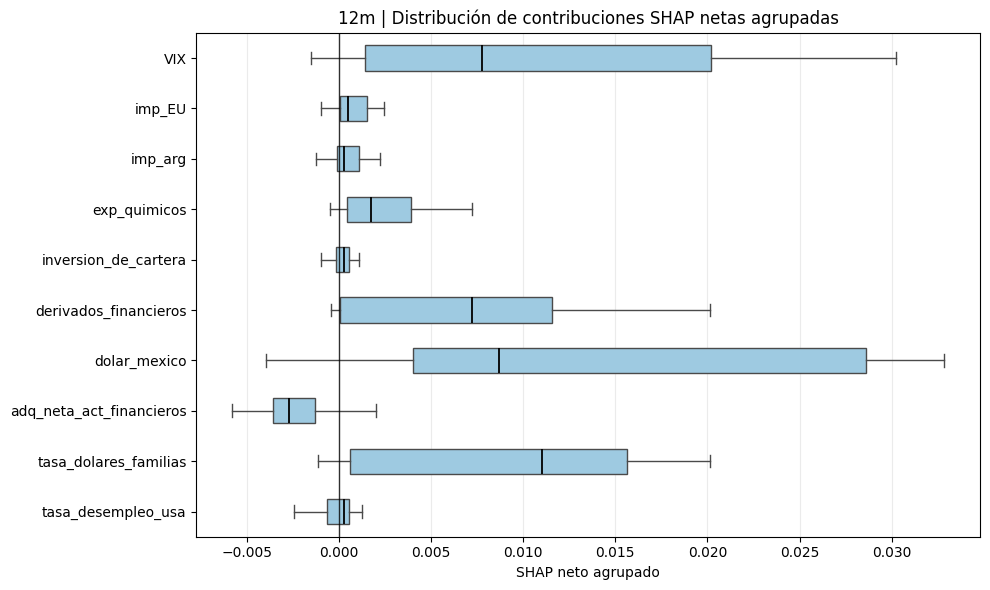

✅ Heatmap de correlación guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\global_shap\corr_top_raw_12m_RandomForest.png


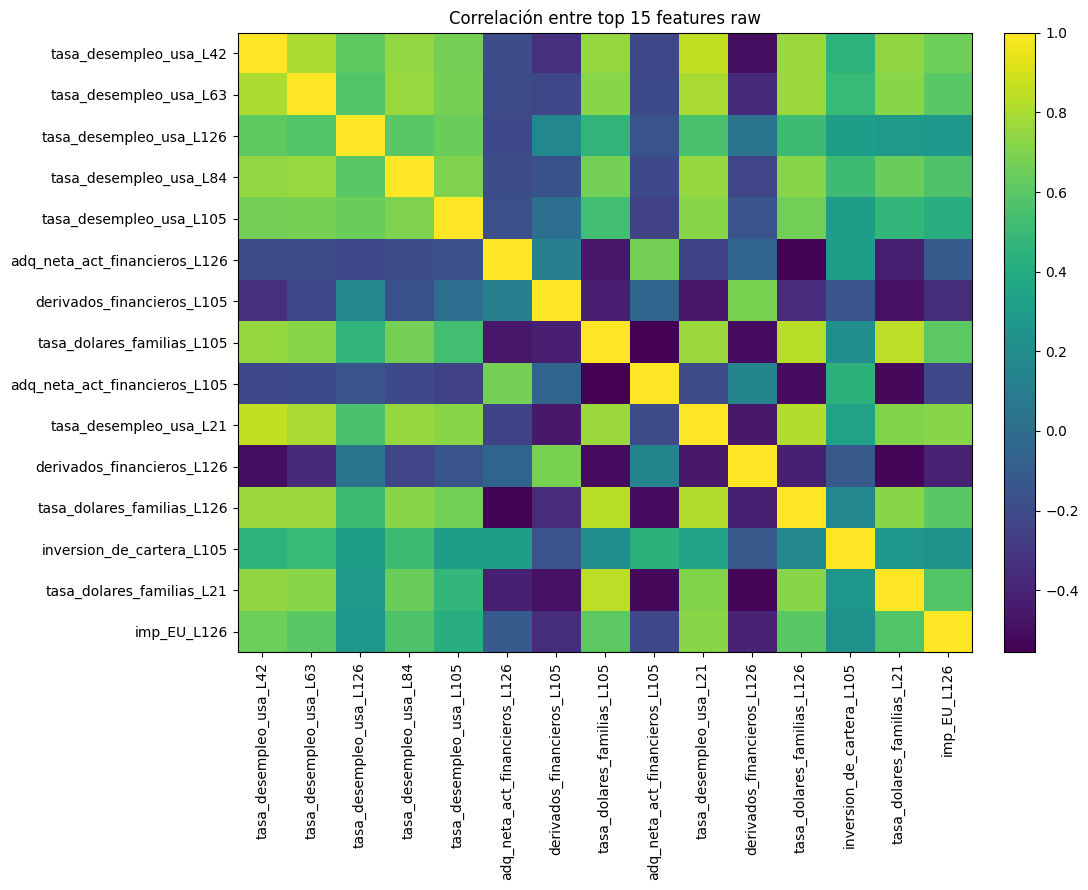

In [11]:

# ==========================================
# 4E) Ejecutar extensión global
# ==========================================
DOMINANT_FEATURE_CHECK = {
    "1m": None,
    "12m": "tasa_desempleo_usa",
}

global_detail_outputs = {}
global_signed_outputs = {}
dominant_feature_tables = {}
dominant_feature_sensitivity = {}
global_corr_tables = {}

for h_tag in FOCUS_HORIZONS:
    if h_tag not in global_outputs:
        continue

    print("\n" + "="*90)
    print(f"EXTENSIÓN GLOBAL | {h_tag}")
    print("="*90)

    out = ensure_global_detail_bundle(h_tag, force_if_needed=True)
    global_detail_outputs[h_tag] = out

    # 1) Dirección y dispersión para las top variables del grouped oficial
    signed_out = plot_grouped_signed_boxplot(
        h_tag=h_tag,
        out=out,
        top_k=GLOBAL_TOP_K_GROUPED,
        save=True
    )
    global_signed_outputs[h_tag] = signed_out

    # 2) Correlación entre top raw (auditoría interna)
    corr = plot_top_raw_correlation(out, top_n=min(15, len(out.get("raw_official", out["raw"]))), save=True)
    global_corr_tables[h_tag] = corr
    corr.to_csv(OUT_TABLES_DIR / f"corr_top_raw_{h_tag}.csv")



## 5. Búsqueda de fechas candidatas para interpretabilidad local

Antes de fijar manualmente dos fechas, conviene generar un set de candidatas usando el OOS del mejor modelo de ML:

- fechas con **mayor error absoluto**;
- fechas con **mayor predicción de cambio** (en valor absoluto);
- fechas con mayor **distancia predicho vs observado** en retornos.


In [12]:
# ==========================================
# 5) Helpers para OOS y fechas candidatas
# ==========================================
def find_oos_file(h_tag: str, model_safe: str, family: str = "ml"):
    if str(family).lower() == "ml":
        base = BASE_DIR / "results_n04" / "oos"
    else:
        base = BASE_DIR / "results_n05" / "oos"

    candidates = [
        base / f"oos_{h_tag}_{model_safe}.csv",
        base / f"oos_{h_tag}_{model_safe}.xlsx",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def load_oos(h_tag: str, model_safe: str, family: str = "ml") -> pd.DataFrame:
    p = find_oos_file(h_tag, model_safe, family=family)
    if p is None:
        raise FileNotFoundError(f"No encontré OOS para {h_tag}/{model_safe}/{family}")
    df = pd.read_excel(p) if p.suffix.lower() == ".xlsx" else pd.read_csv(p)
    for c in ["Fecha", "fecha", "Fecha_objetivo", "fecha_objetivo"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def candidate_dates_from_oos(df_oos: pd.DataFrame, top_n: int = 10):
    out = df_oos.copy()

    # Normalización de nombres
    cols_lower = {c.lower(): c for c in out.columns}
    pred_col = cols_lower.get("y_pred")
    true_col = cols_lower.get("y_true")
    fecha_col = cols_lower.get("fecha")

    if pred_col and true_col:
        out["abs_error_return"] = (out[true_col] - out[pred_col]).abs()
        out["abs_pred_return"] = out[pred_col].abs()
    if "dolar_pred_tH" in out.columns and "dolar_real_tH" in out.columns:
        out["abs_error_level"] = (out["dolar_real_tH"] - out["dolar_pred_tH"]).abs()
        out["abs_pred_change_level"] = (out["dolar_pred_tH"] - out["dolar_t"]).abs()

    candidates = {}
    if "abs_error_level" in out.columns:
        candidates["top_error_level"] = out.sort_values("abs_error_level", ascending=False).head(top_n)
    if "abs_error_return" in out.columns:
        candidates["top_error_return"] = out.sort_values("abs_error_return", ascending=False).head(top_n)
    if "abs_pred_return" in out.columns:
        candidates["top_abs_pred_return"] = out.sort_values("abs_pred_return", ascending=False).head(top_n)

    return candidates

candidate_store = {}
for h_tag in FOCUS_HORIZONS:
    row = best_ml.loc[best_ml["h_tag"].eq(h_tag)].iloc[0]
    oos = load_oos(h_tag, row["model_safe"], family="ml")
    candidate_store[h_tag] = candidate_dates_from_oos(oos, top_n=8)

    print("\n" + "="*80)
    print(f"CANDIDATAS LOCAL | {h_tag} | modelo ML: {row['model']}")
    print("="*80)
    for name, dfc in candidate_store[h_tag].items():
        print(f"\n>> {name}")
        display(dfc.head(8))



CANDIDATAS LOCAL | 1m | modelo ML: RandomForest

>> top_error_level


,Fecha,Fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,y_true,y_pred,abs_error_return,abs_pred_return,abs_error_level,abs_pred_change_level
84,2022-12-27,2023-01-26,40.08,40.597699,38.93,-0.029112,0.012834,0.041946,0.012834,1.667699,0.517699
494,2024-08-23,2024-09-23,40.25,40.664740,42.25,0.048494,0.010251,0.038243,0.010251,1.585260,0.414740
85,2022-12-28,2023-01-27,39.78,40.169271,38.65,-0.028817,0.009738,0.038556,0.009738,1.519271,0.389271
515,2024-09-23,2024-10-22,42.25,42.975295,41.52,-0.017429,0.017021,0.034450,0.017021,1.455295,0.725295
495,2024-08-26,2024-09-24,40.25,40.753348,42.18,0.046836,0.012428,0.034408,0.012428,1.426652,0.503348
540,2024-10-28,2024-11-26,41.05,41.480081,42.90,0.044081,0.010423,0.033658,0.010423,1.419919,0.430081
541,2024-10-29,2024-11-27,41.23,41.705251,43.07,0.043661,0.011461,0.032200,0.011461,1.364749,0.475251
577,2024-12-18,2025-01-22,44.62,44.767694,43.44,-0.026802,0.003305,0.030106,0.003305,1.327694,0.147694



>> top_error_return


,Fecha,Fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,y_true,y_pred,abs_error_return,abs_pred_return,abs_error_level,abs_pred_change_level
84,2022-12-27,2023-01-26,40.08,40.597699,38.93,-0.029112,0.012834,0.041946,0.012834,1.667699,0.517699
85,2022-12-28,2023-01-27,39.78,40.169271,38.65,-0.028817,0.009738,0.038556,0.009738,1.519271,0.389271
494,2024-08-23,2024-09-23,40.25,40.664740,42.25,0.048494,0.010251,0.038243,0.010251,1.585260,0.414740
515,2024-09-23,2024-10-22,42.25,42.975295,41.52,-0.017429,0.017021,0.034450,0.017021,1.455295,0.725295
495,2024-08-26,2024-09-24,40.25,40.753348,42.18,0.046836,0.012428,0.034408,0.012428,1.426652,0.503348
540,2024-10-28,2024-11-26,41.05,41.480081,42.90,0.044081,0.010423,0.033658,0.010423,1.419919,0.430081
63,2022-11-28,2022-12-27,39.50,38.787277,40.08,0.014577,-0.018208,0.032785,0.018208,1.292723,0.712723
541,2024-10-29,2024-11-27,41.23,41.705251,43.07,0.043661,0.011461,0.032200,0.011461,1.364749,0.475251



>> top_abs_pred_return


...

,Fecha,Fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,y_true,y_pred,abs_error_return,abs_pred_return,abs_error_level,abs_pred_change_level
0,2022-01-03,2023-01-05,44.61,42.049901,39.90,-0.111582,-0.059101,0.052481,0.059101,2.149901,2.560099
495,2024-01-02,2025-01-03,39.15,41.868752,43.96,0.115880,0.067139,0.048740,0.067139,2.091248,2.718752
1,2022-01-04,2023-01-09,44.73,41.775010,39.85,-0.115522,-0.068346,0.047176,0.068346,1.925010,2.954990
474,2023-11-30,2024-12-02,39.11,41.334311,43.15,0.098304,0.055315,0.042989,0.055315,1.815689,2.224311
132,2022-07-15,2023-07-24,42.20,39.540951,37.82,-0.109582,-0.065083,0.044499,0.065083,1.720951,2.659049
41,2022-03-04,2023-03-08,42.68,40.710670,39.18,-0.085564,-0.047240,0.038324,0.047240,1.530670,1.969330
131,2022-07-14,2023-07-21,41.90,39.450663,37.95,-0.099016,-0.060235,0.038781,0.060235,1.500663,2.449337
618,2024-07-02,2025-07-04,40.28,41.652815,40.18,-0.002486,0.033514,0.036000,0.033514,1.472815,1.372815



>> top_error_return


,Fecha,Fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,y_true,y_pred,abs_error_return,abs_pred_return,abs_error_level,abs_pred_change_level
0,2022-01-03,2023-01-05,44.61,42.049901,39.90,-0.111582,-0.059101,0.052481,0.059101,2.149901,2.560099
495,2024-01-02,2025-01-03,39.15,41.868752,43.96,0.115880,0.067139,0.048740,0.067139,2.091248,2.718752
1,2022-01-04,2023-01-09,44.73,41.775010,39.85,-0.115522,-0.068346,0.047176,0.068346,1.925010,2.954990
132,2022-07-15,2023-07-24,42.20,39.540951,37.82,-0.109582,-0.065083,0.044499,0.065083,1.720951,2.659049
474,2023-11-30,2024-12-02,39.11,41.334311,43.15,0.098304,0.055315,0.042989,0.055315,1.815689,2.224311
131,2022-07-14,2023-07-21,41.90,39.450663,37.95,-0.099016,-0.060235,0.038781,0.060235,1.500663,2.449337
41,2022-03-04,2023-03-08,42.68,40.710670,39.18,-0.085564,-0.047240,0.038324,0.047240,1.530670,1.969330
618,2024-07-02,2025-07-04,40.28,41.652815,40.18,-0.002486,0.033514,0.036000,0.033514,1.472815,1.372815



>> top_abs_pred_return


,Fecha,Fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,y_true,y_pred,abs_error_return,abs_pred_return,abs_error_level,abs_pred_change_level
17,2022-01-27,2023-01-31,44.09,38.834087,38.72,-0.129877,-0.126935,0.002942,0.126935,0.114087,5.255913
16,2022-01-26,2023-01-30,44.23,38.971238,38.70,-0.133564,-0.126579,0.006984,0.126579,0.271238,5.258762
18,2022-01-28,2023-02-01,44.10,38.875276,38.75,-0.129329,-0.126101,0.003228,0.126101,0.125276,5.224724
15,2022-01-25,2023-01-27,44.46,39.278613,38.65,-0.140043,-0.123910,0.016133,0.123910,0.628613,5.181387
14,2022-01-24,2023-01-26,44.52,39.389830,38.93,-0.134173,-0.122431,0.011742,0.122431,0.459830,5.130170
12,2022-01-20,2023-01-24,44.59,39.529225,39.11,-0.131131,-0.120469,0.010662,0.120469,0.419225,5.060775
13,2022-01-21,2023-01-25,44.53,39.481391,39.06,-0.131064,-0.120334,0.010731,0.120334,0.421391,5.048609
19,2022-01-31,2023-02-02,44.15,39.197651,38.85,-0.127885,-0.118976,0.008909,0.118976,0.347651,4.952349


### 5B. Selección manual de fechas

Una vez vistas las candidatas, elegí dos fechas para la tesis.  
Por ahora dejo un ejemplo editable.

**Importante:** la fecha debe corresponder a la `Fecha` origen de la predicción, no a `Fecha_objetivo`.


In [18]:
# ==========================================
# 5B) Fechas seleccionadas manualmente
# ==========================================
SELECTED_LOCAL_DATES = {
    "1m": [
        "2020-03-16",
        "2024-09-02",
    ],
    "12m": [
        "2020-03-16",
        "2024-09-02",
    ],
}

# Convertimos a datetime
for k, vals in SELECTED_LOCAL_DATES.items():
    SELECTED_LOCAL_DATES[k] = [pd.to_datetime(v) for v in vals]

SELECTED_LOCAL_DATES


{'1m': [Timestamp('2020-03-16 00:00:00'), Timestamp('2024-09-02 00:00:00')],
 '12m': [Timestamp('2020-03-16 00:00:00'), Timestamp('2024-09-02 00:00:00')]}

## 6. SHAP local para el mejor modelo ML

Esta sección recalcula SHAP a nivel observación para las fechas elegidas y genera:

- waterfall plot;
- tabla con contribuciones ordenadas;
- resumen con predicción, valor base y suma de contribuciones.


In [43]:
# ==========================================
# 6) Helpers para SHAP local
# ==========================================
def aggregate_local_contrib_table(contrib_raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega contribuciones SHAP por variable base.
    """
    g = (
        contrib_raw_df.groupby("feature_base", as_index=False)
        .agg(
            shap_value=("shap_value", "sum"),
            abs_shap=("abs_shap", "sum"),
        )
        .sort_values("abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    total_abs = g["abs_shap"].sum()
    g["share_abs_local"] = np.where(total_abs > 0, g["abs_shap"] / total_abs, np.nan)
    g["share_abs_local_pct"] = 100 * g["share_abs_local"]
    g["sign"] = np.where(g["shap_value"] >= 0, "positive", "negative")
    return g


def compute_local_shap_for_dates(
    h_tag: str,
    model_name: str,
    model_safe: str,
    selected_dates,
    bg_n_samples: int = SHAP_BG_SAMPLES
):
    import shap

    art = load_ml_artifact(h_tag, model_safe)
    X_all, y_all, dates_all = build_X_exact_from_artifact(h_tag, art["features"])

    idx_map = pd.Series(np.arange(len(dates_all)), index=pd.to_datetime(dates_all))
    selected_dates = [pd.to_datetime(d) for d in selected_dates]

    missing_dates = [d for d in selected_dates if d not in idx_map.index]
    if missing_dates:
        raise ValueError(f"No encontré estas fechas en el dataset modelado: {missing_dates}")

    idxs = [int(idx_map[d]) for d in selected_dates]
    X_local = X_all.iloc[idxs].copy()

    bg_n = min(int(bg_n_samples), len(X_all))
    X_bg = X_all.iloc[:bg_n].copy()

    explainer = shap.TreeExplainer(art["model"], data=X_bg)
    shap_values = explainer.shap_values(X_local)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)

    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.asarray(base_value).ravel()[0]

    preds = art["model"].predict(X_local)

    rows = []
    contrib_tables = {}
    contrib_tables_raw = {}

    for i, d in enumerate(selected_dates):
        sv = shap_values[i]
        x_row = X_local.iloc[i]

        tmp_raw = pd.DataFrame({
            "feature": X_local.columns,
            "feature_base": [base_feature_name(c) for c in X_local.columns],
            "feature_value": x_row.values,
            "shap_value": sv,
            "abs_shap": np.abs(sv),
            "sign": np.where(sv >= 0, "positive", "negative"),
        }).sort_values("abs_shap", ascending=False).reset_index(drop=True)

        tmp_grouped = aggregate_local_contrib_table(tmp_raw)

        contrib_tables_raw[d] = tmp_raw
        contrib_tables[d] = tmp_grouped

        rows.append({
            "h_tag": h_tag,
            "fecha_origen": d,
            "base_value_dlog": float(base_value),
            "prediction_dlog": float(preds[i]),
            "sum_shap": float(sv.sum()),
            "base_plus_shap": float(base_value + sv.sum()),
        })

    summary = pd.DataFrame(rows)

    return {
        "artifact": art,
        "X_local": X_local,
        "dates_local": selected_dates,
        "summary": summary,
        "contrib_tables": contrib_tables,          # agregado por variable base
        "contrib_tables_raw": contrib_tables_raw,  # raw por si querés auditar
        "base_value": float(base_value),
    }


def plot_local_waterfall_from_table(
    contrib_df,
    title="",
    max_display=12,
    save_path=None,
    value_col="shap_value",
    xlabel=None,
    pred_level=None,
    real_level=None,
    dolar_t=None,
    fecha_objetivo=None,
):
    """
    value_col:
      - 'shap_value'            -> gráfico exacto en escala del target (usd_dlog)
      - 'impacto_aprox_nivel'   -> gráfico aproximado en niveles del TC
    """
    top = contrib_df.head(max_display).copy().sort_values(value_col)
    colors = np.where(top[value_col] >= 0, "#2ca02c", "#d62728")

    fig, ax = plt.subplots(figsize=(10.8, 5.4))

    ax.barh(top["feature_base"], top[value_col], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.grid(axis="x", alpha=0.25)

    if xlabel is None:
        xlabel = "Contribución SHAP agregada a la predicción" if value_col == "shap_value" else "Impacto aproximado en niveles del TC"

    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=14, pad=18)

    meta_parts = []
    if pd.notna(dolar_t):
        meta_parts.append(f"TC base: {dolar_t:.3f}")
    if pd.notna(pred_level):
        meta_parts.append(f"Pred: {pred_level:.3f}")
    if pd.notna(real_level):
        meta_parts.append(f"Real: {real_level:.3f}")
    if pd.notna(fecha_objetivo):
        meta_parts.append(f"Fecha objetivo: {pd.to_datetime(fecha_objetivo).date()}")

    if meta_parts:
        subtitle = " | ".join(meta_parts)
        ax.text(
            0.5, 1.01, subtitle,
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=10, color="dimgray"
        )

    x_min = float(top[value_col].min())
    x_max = float(top[value_col].max())
    x_span = max(x_max - x_min, 1e-9)

    pad = max(x_span * 0.10, 0.00025 if value_col == "shap_value" else 0.03)
    text_offset = max(x_span * 0.012, 0.00004 if value_col == "shap_value" else 0.01)

    fmt = "{:.4f}" if value_col == "shap_value" else "{:.3f}"

    for i, v in enumerate(top[value_col]):
        ax.text(
            v + (text_offset if v >= 0 else -text_offset),
            i,
            fmt.format(v),
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=8,
        )

    ax.set_xlim(x_min - pad, x_max + pad)

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if save_path is not None:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
        print("✅ Guardado:", save_path)

    plt.show()

def join_local_with_oos(local_summary_df, h_tag, model_safe=None):
    """
    Construye el contexto local DIRECTAMENTE desde la base modelada y la serie en niveles.
    NO depende del archivo OOS.

    Devuelve:
      - fecha_origen
      - Fecha_objetivo
      - dolar_t
      - dolar_real_tH
      - prediction_dlog
      - dolar_pred_tH
    """
    H = HORIZONS[h_tag]
    df_base = get_df_for_tag(h_tag).copy()

    # Base con fechas limpias
    df_base = df_base.copy()
    df_base[DATE_COL] = pd.to_datetime(df_base[DATE_COL], errors="coerce")
    df_base = df_base.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)

    # Mapa fecha -> índice en la base original del horizonte
    idx_map = pd.Series(df_base.index.values, index=pd.to_datetime(df_base[DATE_COL]))

    out = local_summary_df.copy()
    out["fecha_origen"] = pd.to_datetime(out["fecha_origen"])

    rows = []

    for _, r in out.iterrows():
        fecha_origen = pd.to_datetime(r["fecha_origen"])

        if fecha_origen not in idx_map.index:
            rows.append({
                **r.to_dict(),
                "Fecha_objetivo": pd.NaT,
                "dolar_t": np.nan,
                "dolar_real_tH": np.nan,
                "dolar_pred_tH": np.nan,
            })
            continue

        idx0 = int(idx_map.loc[fecha_origen])
        idxH = idx0 + H

        # Fecha objetivo desde la misma base del horizonte
        if idxH >= len(df_base):
            fecha_objetivo = pd.NaT
        else:
            fecha_objetivo = pd.to_datetime(df_base.loc[idxH, DATE_COL])

        # Nivel del dólar en t y t+H
        dolar_t = np.nan
        dolar_real_tH = np.nan

        if df_level is not None:
            row_t = df_level.loc[df_level["Fecha"].eq(fecha_origen)]
            if len(row_t) > 0:
                dolar_t = float(row_t["dolar"].iloc[0])

            if pd.notna(fecha_objetivo):
                row_H = df_level.loc[df_level["Fecha"].eq(fecha_objetivo)]
                if len(row_H) > 0:
                    dolar_real_tH = float(row_H["dolar"].iloc[0])

        # Predicción en niveles a partir del dlog predicho
        pred_dlog = r.get("prediction_dlog", np.nan)
        if pd.notna(dolar_t) and pd.notna(pred_dlog):
            dolar_pred_tH = float(dolar_t * np.exp(pred_dlog))
        else:
            dolar_pred_tH = np.nan

        rows.append({
            **r.to_dict(),
            "Fecha_objetivo": fecha_objetivo,
            "dolar_t": dolar_t,
            "dolar_real_tH": dolar_real_tH,
            "dolar_pred_tH": dolar_pred_tH,
        })

    merged = pd.DataFrame(rows)
    return merged

def add_local_level_impacts(contrib_df: pd.DataFrame, pred_level: float):
    """
    Traducción aproximada de la contribución local a niveles.

    Aproximación:
      impacto_aprox_nivel = pred_level * (exp(shap_value) - 1)

    No es SHAP exacto en niveles, pero sí una traducción interpretativa útil.
    """
    out = contrib_df.copy()

    if pd.isna(pred_level):
        out["impacto_aprox_nivel"] = np.nan
        return out

    out["impacto_aprox_nivel"] = pred_level * (np.exp(out["shap_value"]) - 1)
    return out


LOCAL SHAP | h_tag=1m | model=RandomForest


,h_tag,fecha_origen,base_value_dlog,prediction_dlog,sum_shap,base_plus_shap,Fecha_objetivo,dolar_t,dolar_real_tH,dolar_pred_tH
0,1m,2020-03-16,0.017296,-0.023885,-0.041189,-0.023893,2020-04-16,45.53,43.5,44.455415
1,1m,2024-09-02,0.017296,0.017056,-0.000248,0.017048,2024-10-01,40.28,41.8,40.972920


,h_tag,model,fecha_origen,fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,feature_base,shap_value,abs_shap,share_abs_local,share_abs_local_pct,sign,impacto_aprox_nivel
0,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,dolar_mexico,-0.011843,0.011843,0.199277,19.927745,negative,-0.523362
1,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,VIX,-0.006392,0.006392,0.107563,10.756348,negative,-0.283264
2,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,IMESI,-0.002281,0.002823,0.047504,4.750415,negative,-0.101279
3,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,exp_EU,0.001345,0.002722,0.045804,4.580398,positive,0.059842
4,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,int_deuda_gob,0.000333,0.002719,0.045760,4.575971,positive,0.014791
5,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,inversion_de_cartera,-0.000103,0.002354,0.039614,3.961390,negative,-0.004562
6,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,adq_neta_act_financieros,-0.001771,0.002121,0.035684,3.568408,negative,-0.078667
7,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,int_ANCAP,-0.002030,0.002037,0.034272,3.427178,negative,-0.090173
8,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,IRAE,-0.001309,0.001793,0.030164,3.016436,negative,-0.058158
9,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.5,tasa_dolares_familias,-0.000885,0.001719,0.028928,2.892762,negative,-0.039311


✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_dlog_1m_RandomForest_20200316.png


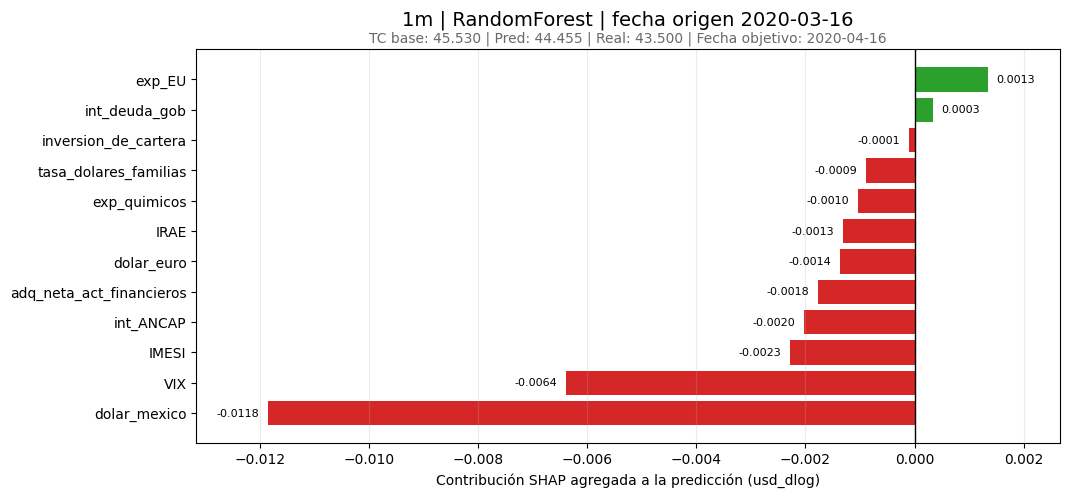

✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_level_1m_RandomForest_20200316.png


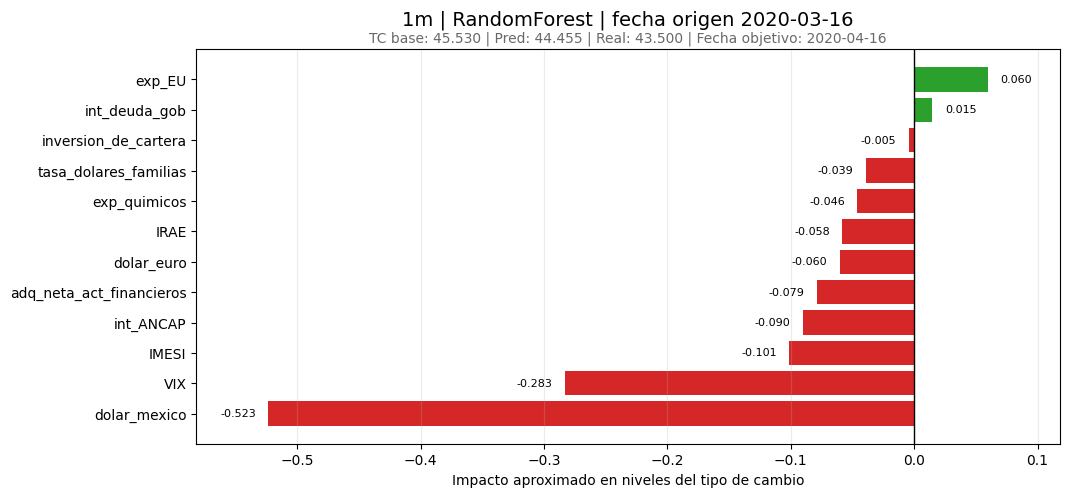

,h_tag,model,fecha_origen,fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,feature_base,shap_value,abs_shap,share_abs_local,share_abs_local_pct,sign,impacto_aprox_nivel
0,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,exp_arg,-0.000601,0.001247,0.057772,5.777180,negative,-0.024630
1,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,imp_EU,0.000833,0.001218,0.056442,5.644162,positive,0.034131
2,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,tasa_dolares_familias,-0.001026,0.001127,0.052238,5.223766,negative,-0.042013
3,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,exp_brl,-0.000348,0.001115,0.051651,5.165069,negative,-0.014247
4,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,imp_patrimonio,0.000287,0.001049,0.048623,4.862312,positive,0.011768
5,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,int_ANCAP,-0.000770,0.001029,0.047670,4.766990,negative,-0.031553
6,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,inversion_de_cartera,-0.000637,0.000941,0.043596,4.359597,negative,-0.026082
7,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,exp_madera,0.000843,0.000887,0.041079,4.107864,positive,0.034543
8,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,dolar_mexico,-0.000660,0.000851,0.039411,3.941077,negative,-0.027021
9,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.97292,41.8,IMESI,-0.000768,0.000848,0.039295,3.929526,negative,-0.031468


✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_dlog_1m_RandomForest_20240902.png


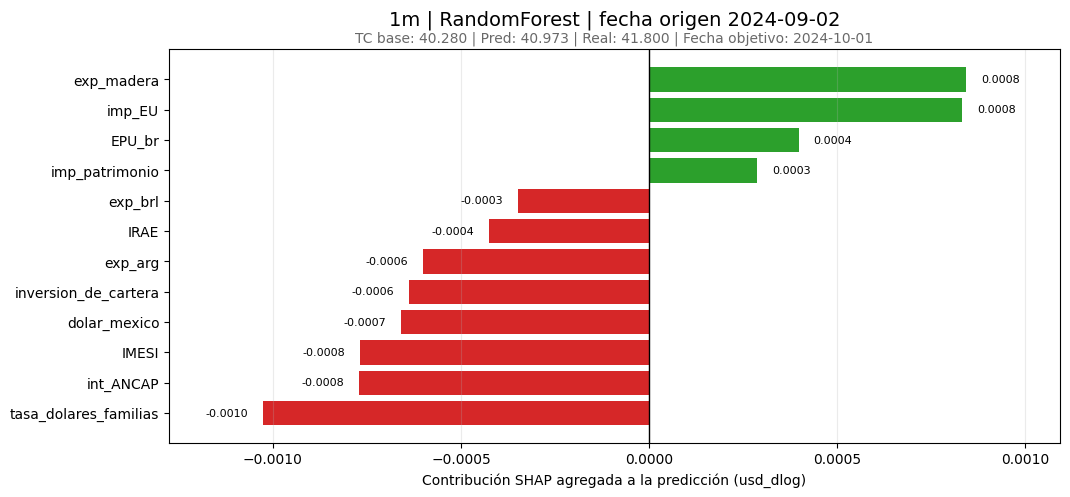

✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_level_1m_RandomForest_20240902.png


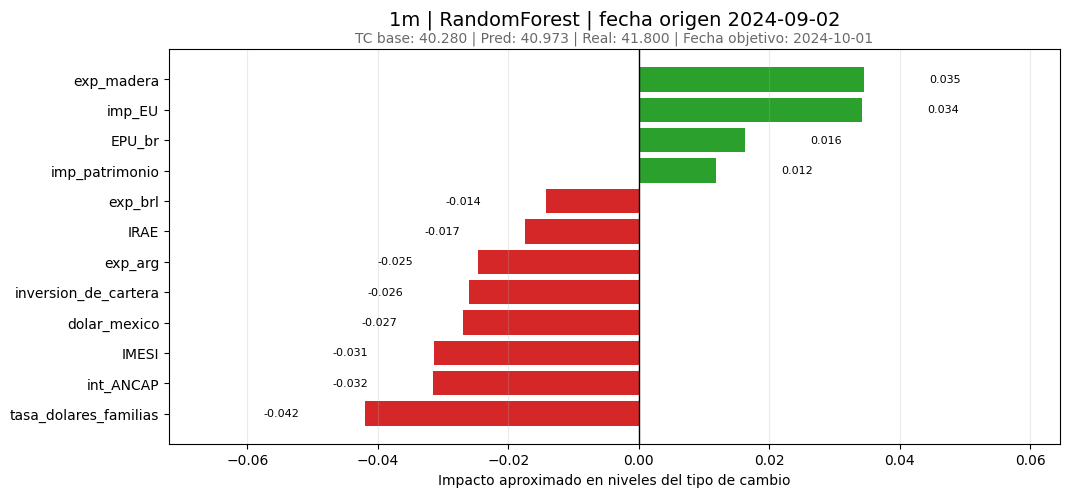


LOCAL SHAP | h_tag=12m | model=RandomForest


,h_tag,fecha_origen,base_value_dlog,prediction_dlog,sum_shap,base_plus_shap,Fecha_objetivo,dolar_t,dolar_real_tH,dolar_pred_tH
0,12m,2020-03-16,-0.057363,-0.008420,0.048961,-0.008402,2021-03-23,45.53,44.11,45.148268
1,12m,2024-09-02,-0.057363,0.005077,0.062457,0.005094,2025-09-05,40.28,39.97,40.485021


,h_tag,model,fecha_origen,fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,feature_base,shap_value,abs_shap,share_abs_local,share_abs_local_pct,sign,impacto_aprox_nivel
0,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,tasa_desempleo_usa,0.026961,0.026961,0.211542,21.154156,positive,1.233788
1,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,dolar_mexico,-0.011128,0.011128,0.087315,8.731502,negative,-0.499634
2,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,pas_gob,0.010974,0.010974,0.086109,8.610852,positive,0.498206
3,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,IRAE,0.010117,0.010117,0.079379,7.937948,positive,0.459076
4,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,exp_quimicos,0.009908,0.009908,0.077741,7.774145,positive,0.449555
5,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,VIX,-0.008190,0.008190,0.064260,6.425963,negative,-0.368246
6,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,derivados_financieros,0.003604,0.005244,0.041143,4.114305,positive,0.162995
7,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,adq_neta_act_financieros,0.004326,0.004445,0.034875,3.487526,positive,0.195722
8,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,inversion_de_cartera,-0.002799,0.004431,0.034768,3.476812,negative,-0.126193
9,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,inv_gob,0.003700,0.003700,0.029035,2.903472,positive,0.167378


✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_dlog_12m_RandomForest_20200316.png


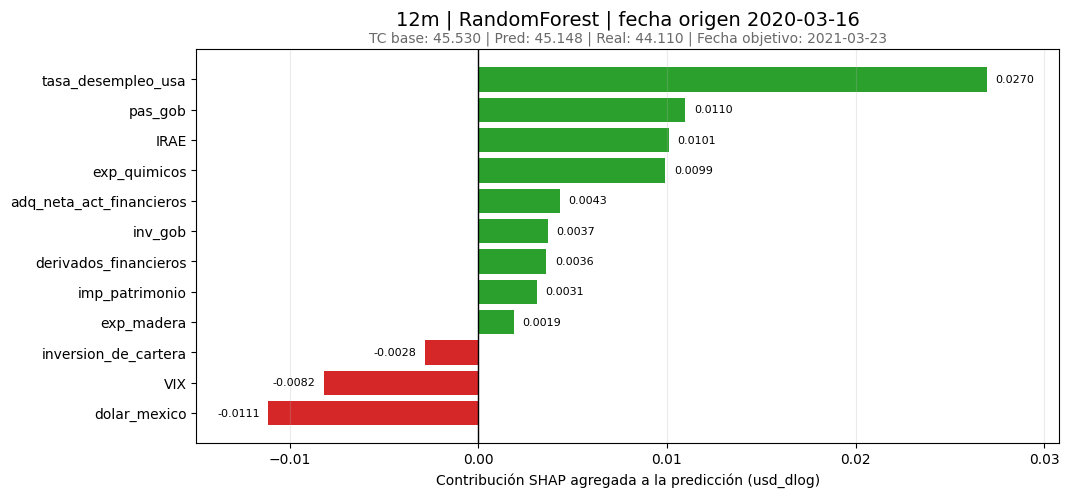

✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_level_12m_RandomForest_20200316.png


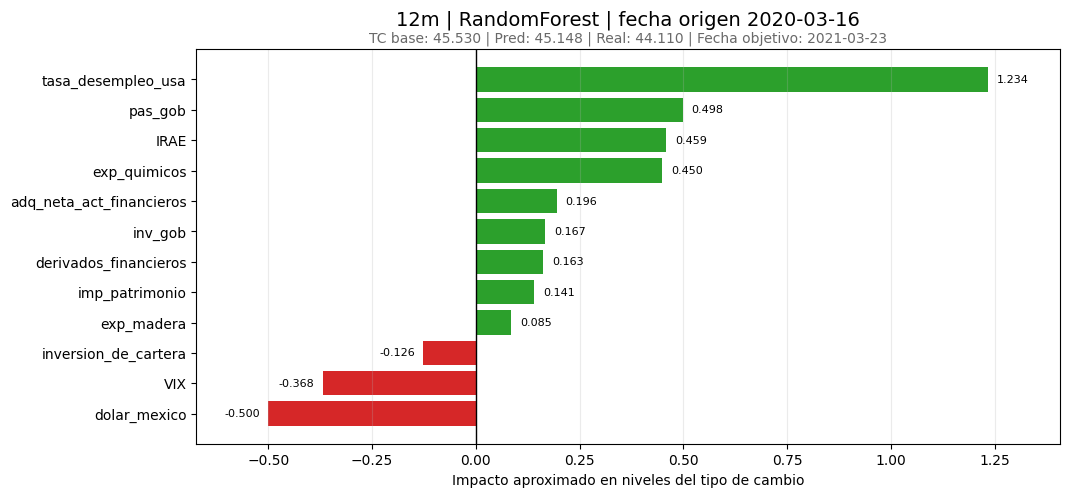

,h_tag,model,fecha_origen,fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,feature_base,shap_value,abs_shap,share_abs_local,share_abs_local_pct,sign,impacto_aprox_nivel
0,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,tasa_desempleo_usa,0.031254,0.031254,0.260411,26.041061,positive,1.285307
1,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,pas_gob,0.015889,0.015889,0.132389,13.238950,positive,0.648414
2,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,IRAE,0.011614,0.011614,0.096770,9.677040,positive,0.472945
3,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,dolar_mexico,-0.009922,0.009922,0.082669,8.266950,negative,-0.399702
4,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,inv_gob,0.005046,0.005046,0.042046,4.204561,positive,0.204815
5,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,venta_autos,0.004962,0.004962,0.041345,4.134489,positive,0.201393
6,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,exp_quimicos,0.004806,0.004869,0.040570,4.057040,positive,0.195056
7,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,inversion_de_cartera,-0.003159,0.003480,0.028996,2.899572,negative,-0.127700
8,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,imp_patrimonio,0.002772,0.002841,0.023672,2.367216,positive,0.112363
9,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,exp_arg,-0.002241,0.002381,0.019836,1.983602,negative,-0.090632


✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_dlog_12m_RandomForest_20240902.png


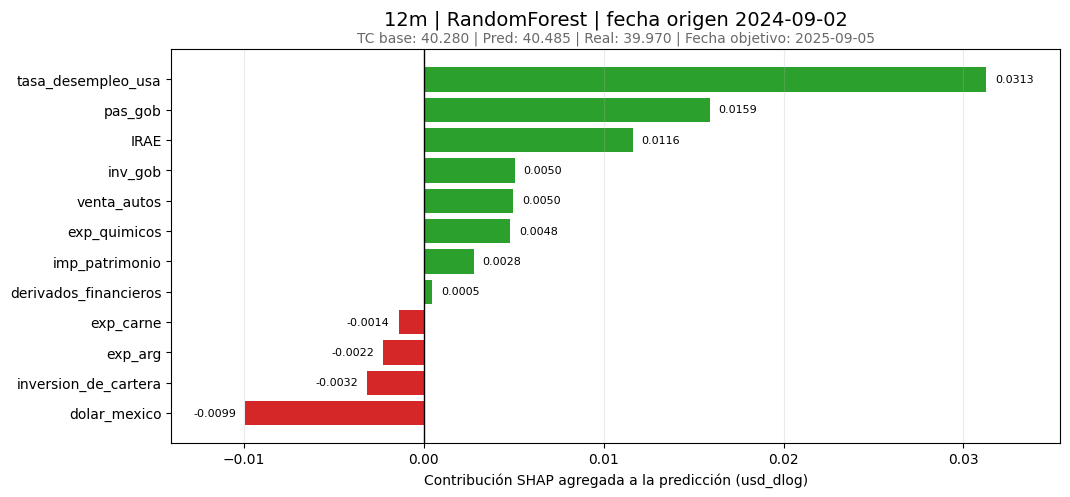

✅ Guardado: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n08\local_shap\local_waterfall_level_12m_RandomForest_20240902.png


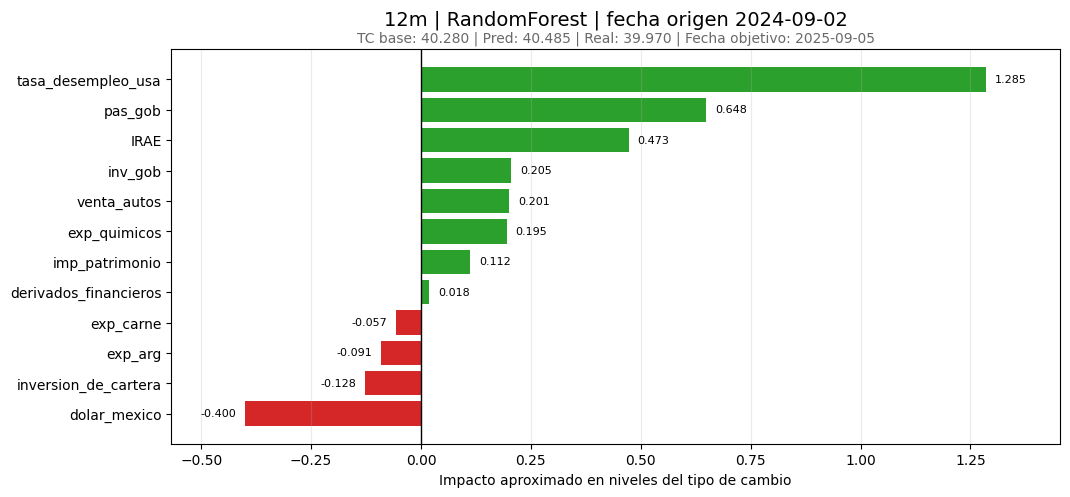

In [44]:
# ==========================================
# 6B) Ejecutar local SHAP para fechas seleccionadas
# ==========================================
local_outputs = {}

for h_tag in FOCUS_HORIZONS:
    dates_sel = SELECTED_LOCAL_DATES.get(h_tag, [])
    if len(dates_sel) == 0:
        print(f"⚠️ No hay fechas seleccionadas todavía para {h_tag}.")
        continue

    row = best_ml.loc[best_ml["h_tag"].eq(h_tag)].iloc[0]
    print("\n" + "="*80)
    print(f"LOCAL SHAP | h_tag={h_tag} | model={row['model']}")
    print("="*80)

    out = compute_local_shap_for_dates(
        h_tag=h_tag,
        model_name=row["model"],
        model_safe=row["model_safe"],
        selected_dates=dates_sel,
        bg_n_samples=SHAP_BG_SAMPLES,
    )
    local_outputs[h_tag] = out

    summary_merged = join_local_with_oos(out["summary"], h_tag, row["model_safe"])
    display(summary_merged)

    for d in out["dates_local"]:
        dfc = out["contrib_tables"][d].copy()
        safe_date = pd.to_datetime(d).strftime("%Y%m%d")
        row_plot = summary_merged.loc[summary_merged["fecha_origen"].eq(pd.to_datetime(d))].iloc[0]

        # Agregar traducción aproximada a niveles
        dfc_level = add_local_level_impacts(
            contrib_df=dfc,
            pred_level=row_plot.get("dolar_pred_tH")
        ).copy()

        # Agregar contexto para que el CSV sea autoexplicativo
        dfc_level.insert(0, "h_tag", h_tag)
        dfc_level.insert(1, "model", row["model"])
        dfc_level.insert(2, "fecha_origen", pd.to_datetime(d))
        dfc_level.insert(3, "fecha_objetivo", row_plot.get("Fecha_objetivo"))
        dfc_level.insert(4, "dolar_t", row_plot.get("dolar_t"))
        dfc_level.insert(5, "dolar_pred_tH", row_plot.get("dolar_pred_tH"))
        dfc_level.insert(6, "dolar_real_tH", row_plot.get("dolar_real_tH"))

        display(dfc_level.head(15))

        # Guardar CSV agrupado por caso
        dfc_level.to_csv(
            OUT_TABLES_DIR / f"local_contrib_{h_tag}_{row['model_safe']}_{safe_date}.csv",
            index=False
        )

        # Guardar raw por auditoría
        raw_case = out["contrib_tables_raw"][d].copy()
        raw_case.insert(0, "h_tag", h_tag)
        raw_case.insert(1, "model", row["model"])
        raw_case.insert(2, "fecha_origen", pd.to_datetime(d))
        raw_case.insert(3, "fecha_objetivo", row_plot.get("Fecha_objetivo"))
        raw_case.insert(4, "dolar_t", row_plot.get("dolar_t"))
        raw_case.insert(5, "dolar_pred_tH", row_plot.get("dolar_pred_tH"))
        raw_case.insert(6, "dolar_real_tH", row_plot.get("dolar_real_tH"))

        raw_case.to_csv(
            OUT_TABLES_DIR / f"local_contrib_raw_{h_tag}_{row['model_safe']}_{safe_date}.csv",
            index=False
        )

        # ----- gráfico exacto en dlog -----
        fig_path_dlog = OUT_LOCAL_DIR / f"local_waterfall_dlog_{h_tag}_{row['model_safe']}_{safe_date}.png"
        plot_local_waterfall_from_table(
            contrib_df=dfc_level,
            title=f"{h_tag} | {row['model']} | fecha origen {pd.to_datetime(d).date()}",
            max_display=SHAP_LOCAL_MAX_FEATURES,
            save_path=fig_path_dlog,
            value_col="shap_value",
            xlabel="Contribución SHAP agregada a la predicción (usd_dlog)",
            pred_level=row_plot.get("dolar_pred_tH"),
            real_level=row_plot.get("dolar_real_tH"),
            dolar_t=row_plot.get("dolar_t"),
            fecha_objetivo=row_plot.get("Fecha_objetivo"),
        )

        # ----- gráfico aproximado en niveles -----
        fig_path_lvl = OUT_LOCAL_DIR / f"local_waterfall_level_{h_tag}_{row['model_safe']}_{safe_date}.png"
        plot_local_waterfall_from_table(
            contrib_df=dfc_level,
            title=f"{h_tag} | {row['model']} | fecha origen {pd.to_datetime(d).date()}",
            max_display=SHAP_LOCAL_MAX_FEATURES,
            save_path=fig_path_lvl,
            value_col="impacto_aprox_nivel",
            xlabel="Impacto aproximado en niveles del tipo de cambio",
            pred_level=row_plot.get("dolar_pred_tH"),
            real_level=row_plot.get("dolar_real_tH"),
            dolar_t=row_plot.get("dolar_t"),
            fecha_objetivo=row_plot.get("Fecha_objetivo"),
        )

## 7. Tabla corta lista para tesis

Esta celda arma una tabla resumida por caso local con:

- fecha origen,
- fecha objetivo,
- valor observado,
- predicción,
- error,
- top drivers positivos,
- top drivers negativos.


In [46]:
# ==========================================
# 7) Tabla corta para tesis
# ==========================================
def make_local_thesis_table(local_outputs: dict, best_ml_df: pd.DataFrame, n_drivers: int = 3):
    rows = []

    for h_tag, out in local_outputs.items():
        model_row = best_ml_df.loc[best_ml_df["h_tag"].eq(h_tag)].iloc[0]
        merged = join_local_with_oos(out["summary"], h_tag, model_row["model_safe"])

        for _, r in merged.iterrows():
            fecha = pd.to_datetime(r["fecha_origen"])
            contrib = out["contrib_tables"][fecha].copy()

            pos = contrib.loc[contrib["shap_value"] > 0].head(n_drivers)["feature_base"].tolist()
            neg = contrib.loc[contrib["shap_value"] < 0].head(n_drivers)["feature_base"].tolist()

            rows.append({
                "h_tag": h_tag,
                "model": model_row["model"],
                "fecha_origen": fecha,
                "fecha_objetivo": r.get("Fecha_objetivo"),
                "dolar_t": r.get("dolar_t"),
                "dolar_pred_tH": r.get("dolar_pred_tH"),
                "dolar_real_tH": r.get("dolar_real_tH"),
                "error_level": (
                    r.get("dolar_real_tH") - r.get("dolar_pred_tH")
                    if pd.notna(r.get("dolar_real_tH")) and pd.notna(r.get("dolar_pred_tH"))
                    else np.nan
                ),
                "drivers_positivos": " | ".join(pos),
                "drivers_negativos": " | ".join(neg),
            })

    return pd.DataFrame(rows)


if len(local_outputs) > 0:
    thesis_local_table = make_local_thesis_table(local_outputs, best_ml, n_drivers=3)
    display(thesis_local_table)
    thesis_local_table.to_csv(OUT_TABLES_DIR / "local_cases_for_thesis.csv", index=False)
else:
    print("⚠️ Todavía no hay salidas locales para construir la tabla.")

,h_tag,model,fecha_origen,fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,error_level,drivers_positivos,drivers_negativos
0,1m,RandomForest,2020-03-16,2020-04-16,45.53,44.455415,43.50,-0.955415,exp_EU | int_deuda_gob | NFCI,dolar_mexico | VIX | IMESI
1,1m,RandomForest,2024-09-02,2024-10-01,40.28,40.972920,41.80,0.827080,imp_EU | imp_patrimonio | exp_madera,exp_arg | tasa_dolares_familias | exp_brl
2,12m,RandomForest,2020-03-16,2021-03-23,45.53,45.148268,44.11,-1.038268,tasa_desempleo_usa | pas_gob | IRAE,dolar_mexico | VIX | inversion_de_cartera
3,12m,RandomForest,2024-09-02,2025-09-05,40.28,40.485021,39.97,-0.515021,tasa_desempleo_usa | pas_gob | IRAE,dolar_mexico | inversion_de_cartera | exp_arg


## 8. Extensión futura: comparación ML vs DL en casos locales

Esta sección queda como recordatorio metodológico.  
Si más adelante decidimos comparar mejor modelo de ML vs mejor modelo de DL para las mismas fechas:

- ML: mantener **TreeSHAP**.
- DL: usar otra técnica de interpretabilidad local (por ejemplo, Integrated Gradients o alguna aproximación compatible con redes).
- No presentar ambas como si fueran exactamente equivalentes.


In [17]:
# Placeholder de trabajo futuro
print("N08 v1 listo. Próximo paso sugerido: correr global 1m/12m y luego fijar dos fechas locales por horizonte.")


N08 v1 listo. Próximo paso sugerido: correr global 1m/12m y luego fijar dos fechas locales por horizonte.
